# Set paths for data source

In [ ]:
labelled_dataset_root = "set labelled dataset folder path (Downloaded from Zenodo) here"

# Breakdown of data splits
distribution of binary labels across data splits 

In [ ]:
import os
from tqdm import tqdm

def count_trains(split_dir):
    labels_dir = os.path.join(split_dir, "labels")

    images_with_trains = 0
    images_without_trains = 0
    images_with_multiple_trains=0
    total_boxes = 0

    for label_file in tqdm(os.listdir(labels_dir), desc=f"Processing {split_dir}"):
        if not label_file.endswith(".txt"):
            continue

        label_path = os.path.join(labels_dir, label_file)

        with open(label_path, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        if len(lines) > 0:
            images_with_trains += 1
            total_boxes += len(lines)
            if len(lines) > 1:
                images_with_multiple_trains+=1
        else:
            images_without_trains += 1

    total_images = images_with_trains + images_without_trains

    return {
        "total_images": total_images,
        "images_with_trains": images_with_trains,
        "images_with_multiple_trains": images_with_multiple_trains,
        "images_without_trains": images_without_trains,
        "total_train_instances": total_boxes
    }


# Root directory of your dataset
dataset_root = f"{labelled_dataset_root}/binary_labels/"

for split in ["train", "validation", "test"]:
    split_path = os.path.join(dataset_root, split)
    stats = count_trains(split_path)

    print(f"\n📁 {split.upper()} SET")
    for k, v in stats.items():
        print(f"{k}: {v}")

Processing /data22/datasets/zollner_dataset/paper_data/TWIST_dataset/train: 100%|██████████| 8000/8000 [00:00<00:00, 28950.74it/s]



📁 TRAIN SET
total_images: 8000
images_with_trains: 6487
images_with_multiple_trains: 17
images_without_trains: 1513
total_train_instances: 6504


Processing /data22/datasets/zollner_dataset/paper_data/TWIST_dataset/validation: 100%|██████████| 1000/1000 [00:00<00:00, 29421.12it/s]



📁 VALIDATION SET
total_images: 1000
images_with_trains: 821
images_with_multiple_trains: 4
images_without_trains: 179
total_train_instances: 825


Processing /data22/datasets/zollner_dataset/paper_data/TWIST_dataset/test: 100%|██████████| 1001/1001 [00:00<00:00, 31242.78it/s]


📁 TEST SET
total_images: 1000
images_with_trains: 808
images_with_multiple_trains: 3
images_without_trains: 192
total_train_instances: 811


# BBOX size distrubution and saved images accordingly

#### based of bbox area 

In [ ]:
import shutil
from pathlib import Path
from typing import Tuple, List, Optional
from tqdm import tqdm

IMG_EXTS = {".jpg", ".jpeg", ".png"}


def yolo_labels_dir_from_images_dir(images_dir: Path) -> Path:
    """
    Typical YOLO layout:
      .../images/<split>/xxx.jpg  -> .../labels/<split>/xxx.txt
      .../images/xxx.jpg          -> .../labels/xxx.txt
    This function replaces '/images' with '/labels' in the path (first occurrence).
    """
    s = str(images_dir)
    if "/images" in s:
        return Path(s.replace("/images", "/labels", 1))
    return images_dir.parent / "labels"


def parse_yolo_label_file(label_path: Path) -> List[Tuple[int, float, float, float, float]]:
    """
    Each line: cls xc yc w h  (normalized)
    Returns list of tuples.
    """
    rows = []
    txt = label_path.read_text().strip()
    if not txt:
        return rows

    for line in txt.splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls = int(float(parts[0]))
        xc, yc, w, h = map(float, parts[1:5])
        rows.append((cls, xc, yc, w, h))
    return rows


def image_bucket_for_file(
    label_path: Path,
    mini_thr: float = 0.10,
    small_thr: float = 0.30,
    large_thr: float = 0.60,
    mode: str = "max_area",
) -> Optional[str]:
    """
    Decide bucket for an IMAGE based on bbox AREA (w*h).

    mode:
      - "max_area": largest bbox area in image decides
      - "any_box": assigns to the largest bucket present
    """
    boxes = parse_yolo_label_file(label_path)
    if not boxes:
        return None  # background / empty label

    # compute bbox area for each box
    areas = [w * h for (_, _, _, w, h) in boxes]

    if mode == "max_area":
        a = max(areas)  # largest object area decides
        if a < mini_thr:
            return "mini"
        elif a <= small_thr:
            return "small"
        elif a <= large_thr:
            return "medium"
        else:
            return "large"

    elif mode == "any_box":
        if any(a > large_thr for a in areas):
            return "large"
        if any((a >= small_thr) and (a <= large_thr) for a in areas):
            return "medium"
        if any((a >= mini_thr) and (a <= small_thr) for a in areas):
            return "small"
        return "mini"

    else:
        raise ValueError(f"Unknown mode: {mode}")


def copy_pair(img_path: Path, label_path: Path, out_images: Path, out_labels: Path):
    out_images.mkdir(parents=True, exist_ok=True)
    out_labels.mkdir(parents=True, exist_ok=True)

    shutil.copy2(img_path, out_images / img_path.name)
    shutil.copy2(label_path, out_labels / label_path.name)


def main(
    images_dir: str,
    out_root: str,
    mini_thr: float = 0.10,
    small_thr: float = 0.25,
    medium_thr: float = 0.50,
    include_background: bool = False,
    mode: str = "max_area",
):
    images_dir = Path(images_dir)
    labels_dir = yolo_labels_dir_from_images_dir(images_dir)

    if not images_dir.exists():
        raise FileNotFoundError(f"Images dir not found: {images_dir}")
    if not labels_dir.exists():
        print(f"[WARN] Labels dir not found: {labels_dir} (will treat all as background)")

    out_root = Path(out_root)

    buckets = ["mini", "small", "medium", "large"] + (["background"] if include_background else [])
    counts = {b: 0 for b in buckets}
    missing_labels = 0

    img_files = [p for p in images_dir.iterdir() if p.suffix.lower() in IMG_EXTS and p.is_file()]

    print(f"[INFO] Found {len(img_files)} images in {images_dir}")
    print(f"[INFO] Labels dir: {labels_dir}")
    print(f"[INFO] Buckets by bbox area:")
    print(f"       mini   <  {mini_thr:.2f} ({mini_thr*100:.1f}%)")
    print(f"       small  <= {small_thr:.2f} ({small_thr*100:.1f}%)")
    print(f"       medium <= {medium_thr:.2f} ({medium_thr*100:.1f}%)")
    print(f"       large  >  {medium_thr:.2f} ({medium_thr*100:.1f}%)")
    print(f"[INFO] Decision mode: {mode}")

    for img_path in tqdm(img_files, desc="Processing images"):
        label_path = labels_dir / f"{img_path.stem}.txt"

        if not label_path.exists():
            missing_labels += 1
            if include_background:
                out_img_dir = out_root / "background" / "images"
                out_lbl_dir = out_root / "background" / "labels"
                out_img_dir.mkdir(parents=True, exist_ok=True)
                out_lbl_dir.mkdir(parents=True, exist_ok=True)

                shutil.copy2(img_path, out_img_dir / img_path.name)
                (out_lbl_dir / f"{img_path.stem}.txt").write_text("")
                counts["background"] += 1
            continue

        bucket = image_bucket_for_file(
            label_path,
            mini_thr=mini_thr,
            small_thr=small_thr,
            large_thr=medium_thr,
            mode=mode
        )

        if bucket is None:
            if include_background:
                out_img_dir = out_root / "background" / "images"
                out_lbl_dir = out_root / "background" / "labels"
                out_img_dir.mkdir(parents=True, exist_ok=True)
                out_lbl_dir.mkdir(parents=True, exist_ok=True)

                shutil.copy2(img_path, out_img_dir / img_path.name)
                shutil.copy2(label_path, out_lbl_dir / label_path.name)
                counts["background"] += 1
            continue

        out_img_dir = out_root / bucket / "images"
        out_lbl_dir = out_root / bucket / "labels"
        copy_pair(img_path, label_path, out_img_dir, out_lbl_dir)
        counts[bucket] += 1

    print("\n=== DONE ===")
    for b in buckets:
        print(f"{b:>10}: {counts[b]}")
    print(f"missing_labels: {missing_labels}")
    print(f"Output root: {out_root}")


if __name__ == "__main__":
    IMAGES_DIR = f"{labelled_dataset_root}/images"
    OUT_ROOT = f"{labelled_dataset_root}/bbox_area_buckets"

    main(
        images_dir=IMAGES_DIR,
        out_root=OUT_ROOT,
        mini_thr=0.10,     # <10% area
        small_thr=0.3,    # 10% - 25%
        medium_thr=0.70,    # 25% - 50%
        include_background=True,
        mode="max_area",
    )

[INFO] Found 10000 images in /data22/datasets/zollner_dataset/paper_data/images
[INFO] Labels dir: /data22/datasets/zollner_dataset/paper_data/labels
[INFO] Buckets by bbox area:
       mini   <  0.10 (10.0%)
       small  <= 0.30 (30.0%)
       medium <= 0.70 (70.0%)
       large  >  0.70 (70.0%)
[INFO] Decision mode: max_area


Processing images: 100%|██████████| 10000/10000 [00:04<00:00, 2229.77it/s]


=== DONE ===
      mini: 2219
     small: 1798
    medium: 2061
     large: 2039
background: 1883
missing_labels: 0
Output root: /data22/datasets/zollner_dataset/paper_data/bbox_area_buckets


### Draw bbox smaples for each bucket

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
from pathlib import Path
import random
import matplotlib.image as mpimg


def draw_yolo_boxes_matplotlib(ax, img, labels, color="lime"):
    h, w = img.shape[:2]
    ax.imshow(img)
    ax.axis("off")

    for cls, xc, yc, bw, bh in labels:
        x = (xc - bw / 2) * w
        y = (yc - bh / 2) * h
        bw_px = bw * w
        bh_px = bh * h

        rect = patches.Rectangle(
            (x, y),
            bw_px,
            bh_px,
            linewidth=2,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)


def collect_bbox_size_samples(
    images_dir,
    labels_dir,
    samples_per_category=4,
    mini_thr=0.10,   # <10% bbox area
    small_thr=0.30,  # 10% - 30% bbox area
    medium_thr=0.70, # 30% - 70% bbox area
):
    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)

    buckets = {"mini": [], "small": [], "medium": [], "large": []}

    image_files = [p for p in images_dir.glob("*.*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    random.shuffle(image_files)

    for img_path in tqdm(image_files, desc="Collecting bbox size samples"):
        label_path = labels_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            continue

        labels = []
        max_area = None

        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue

                cls, xc, yc, bw, bh = map(float, parts[:5])
                labels.append((cls, xc, yc, bw, bh))

                area = bw * bh
                if max_area is None or area > max_area:
                    max_area = area

        if not labels or max_area is None:
            continue

        # Assign ONE bucket per image based on largest bbox area
        if max_area < mini_thr:
            category = "mini"
        elif max_area <= small_thr:
            category = "small"
        elif max_area <= medium_thr:
            category = "medium"
        else:
            category = "large"

        if len(buckets[category]) < samples_per_category:
            img = mpimg.imread(img_path)
            buckets[category].append((img_path, img, labels, max_area))

        if all(len(v) >= samples_per_category for v in buckets.values()):
            break

    return buckets


def plot_bbox_samples_individual(samples, save_dir=None, dpi=150):
    """
    Plots each sample as its own figure. Optionally saves each figure into save_dir.
    """
    save_dir = Path(save_dir) if save_dir else None
    if save_dir:
        save_dir.mkdir(parents=True, exist_ok=True)

    for cat, items in samples.items():
        for i, (img_path, img, labels, max_area) in enumerate(items):
            fig, ax = plt.subplots(figsize=(6, 6))
            draw_yolo_boxes_matplotlib(ax, img, labels)

            # ax.set_title(f"{cat.upper()} | max bbox area = {max_area:.3f} ({max_area*100:.1f}%)")

            if save_dir:
                out_path = save_dir / f"{cat}_{i}_{img_path.stem}_NEW.pdf"
                plt.savefig(
                    out_path,
                    bbox_inches="tight",
                    pad_inches=0,
                    transparent=True,
                    dpi=dpi,
                    format="pdf"
                )
                plt.close(fig)
            else:
                plt.show()


# -------------------- RUN --------------------
samples = collect_bbox_size_samples(
    images_dir=f"{labelled_dataset_root}/images",
    labels_dir=f"{labelled_dataset_root}/labels",
    samples_per_category=1,
    mini_thr=0.10,    # <10%
    small_thr=0.30,   # 10% - 30%
    medium_thr=0.70,  # 30% - 70%
)

# Show one-by-one (from all buckets if available)
# plot_bbox_samples_individual(samples)

# Or save them:
plot_bbox_samples_individual(samples, save_dir="/home/mal/ultralytics/rail_road_scripts/bbox_distribution_samples/")

# Blurr or Sharp distribution

In [23]:
import cv2
import os
from pathlib import Path

def is_blurry(image_path, threshold=100.0):
    """
    Returns (is_blurry, variance)
    """
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return True, 0.0  # treat unreadable images as blurry

    lap_var = cv2.Laplacian(img, cv2.CV_64F).var()
    return lap_var < threshold, lap_var


def find_blurry_images(images_dir, threshold=100.0):
    images_dir = Path(images_dir)

    blurry = []
    sharp = []

    for img_path in images_dir.glob("*.*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        blur, score = is_blurry(img_path, threshold)

        if blur:
            blurry.append((img_path, score))
        else:
            sharp.append((img_path, score))

    return blurry, sharp


In [ ]:
images_dir = f"{labelled_dataset_root}/images"

blurry, sharp = find_blurry_images(images_dir, threshold=600)

print(f"Total images : {len(blurry) + len(sharp)}")
print(f"Blurry images: {len(blurry)}, {len(blurry)/(len(blurry)+len(sharp))}", )
print(f"Sharp images : {len(sharp)}, {len(sharp)/(len(blurry)+len(sharp))}")

# Print some examples
for p, v in blurry[:10]:
    print(f"BLURRY | {p.name} | score={v:.2f}")


Total images : 10000
Blurry images: 6448, 0.6448
Sharp images : 3552, 0.3552
BLURRY | train_2023-12-18_17.56.26_539.jpg | score=184.74
BLURRY | train_2023-12-10_04.35.46_053.jpg | score=361.85
BLURRY | train_2023-12-10_01.56.20_018.jpg | score=277.41
BLURRY | train_2023-12-09_05.55.05_055.jpg | score=371.55
BLURRY | train_2023-12-10_19.32.19_443.jpg | score=152.03
BLURRY | train_2023-12-18_20.13.35_846.jpg | score=29.12
BLURRY | train_2023-12-18_16.49.27_856.jpg | score=252.39
BLURRY | train_2023-12-18_19.00.49_763.jpg | score=49.01
BLURRY | train_2023-12-10_03.56.24_560.jpg | score=206.85
BLURRY | train_2023-12-18_20.32.01_163.jpg | score=120.87


In [20]:
import matplotlib.pyplot as plt
import cv2
import random


def show_images(image_tuples, title, max_images=12, cols=4):
    """
    image_tuples: list of (Path, score)
    """
    n = min(len(image_tuples), max_images)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()

    # Returns n unique random elements from image_tuples
    random_images = random.sample(image_tuples, n)

    for ax, (img_path, score) in zip(axes, random_images):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax.imshow(img)
        ax.set_title(f"{img_path.name}\nBlur={score:.1f}", fontsize=9)
        ax.axis("off")

    # Hide unused axes
    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


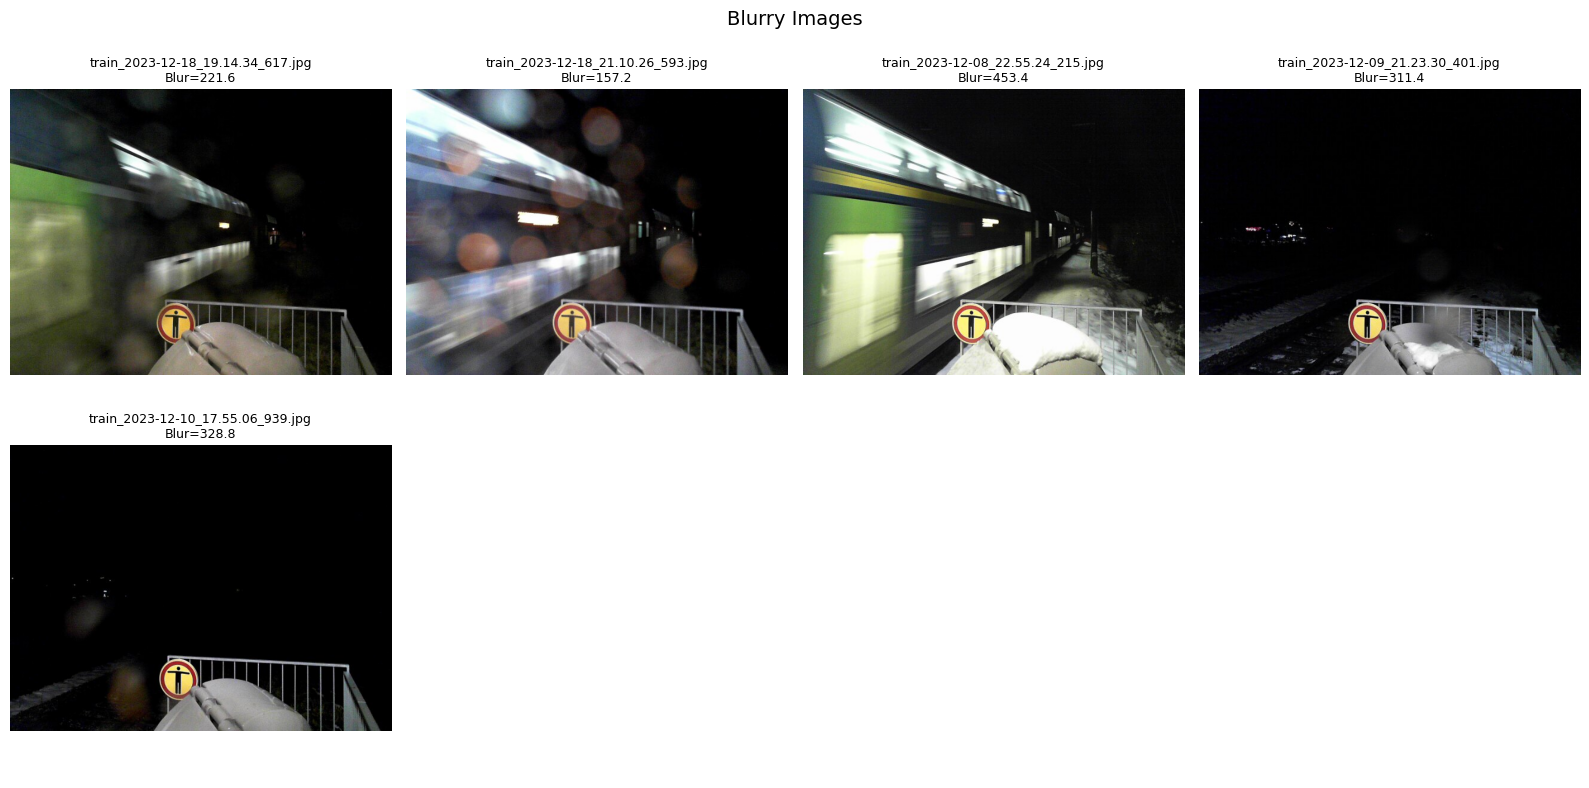

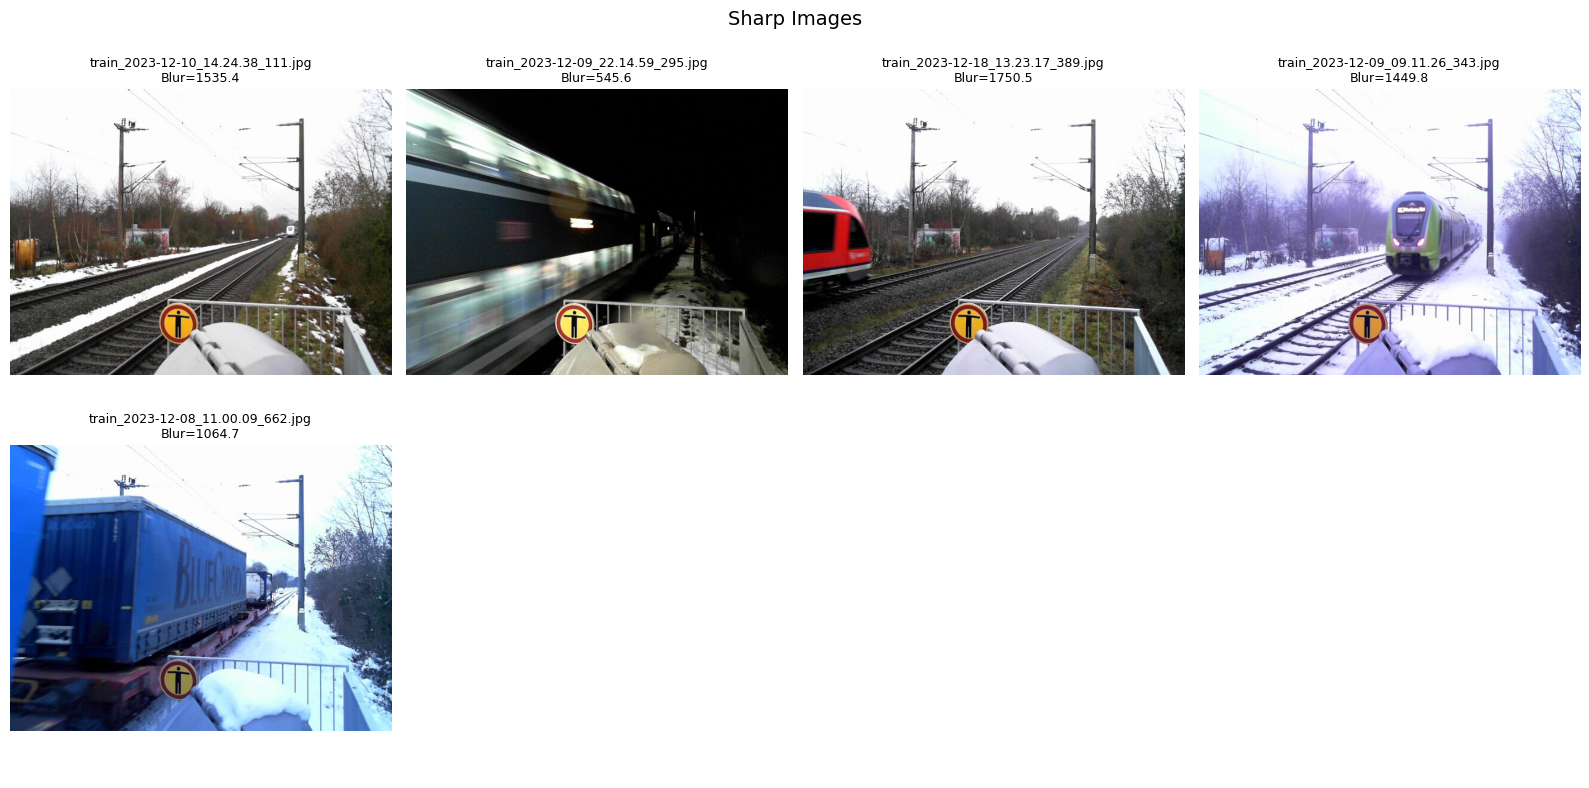

In [27]:
show_images(blurry, title="Blurry Images", max_images=5)
show_images(sharp, title="Sharp Images", max_images=5)



# Snow and Light conditions distribution
Manually labelled with each batch contianing 1000 images.

In [ ]:
import pandas as pd

data = [
    [1, "Light",   "10:59", "16:32",             "Heavy",             304],
    [1, "Dark", "17:25", "06:31",  "Heavy",             696],
    [2, "Dark", "06:31", "07:35",             "Heavy",             133],
    [2, "Light",   "07:56", "14:53",             "Heavy",             867],
    [3, "Light",   "15:11", "16:10",             "Heavy", 161],
    [3, "Dark", "16:29", "00:15",  "Moderate",          839],
    [4, "Dark", "00:15", "07:10",             "Moderate",          636],
    [4, "Light",   "07:53", "11:31",             "Moderate",          364],
    [5, "Light",        "11:31", "16:15",             "Moderate",          530],
    [5, "Dark",      "16:31", "20:10",             "Low",               470],
    [6, "Dark",      "20:10", "07:50",  "Low",              1000],
    [7, "Dark",      "07:50", "08:01",             "Low",                48],
    [7, "Light",        "08:07", "09:31",             "Low",               132],
    [7, "Light",        "11:13", "13:09",             "None",              820],
    [8, "Light", "13:09", "15:57", "None", 740],
    [8, "Dark", "16:27", "16:49", "None", 260],
    [9, "Dark", "16:49", "19:14", "None", 1000],
    [10, "Dark", "19:14", "21:10", "None", 1000]



]

columns = [
    "Batch",
    "Day/Night",
    "Start Time",
    "End Time",
    "Snow",
    "Images"
]

df = pd.DataFrame(data, columns=columns)

df


,Batch,Day/Night,Start Time,End Time,Snow,Images
0,1,Light,10:59,16:32,Heavy,304
1,1,Dark,17:25,06:31,Heavy,696
2,2,Dark,06:31,07:35,Heavy,133
3,2,Light,07:56,14:53,Heavy,867
4,3,Light,15:11,16:10,Heavy,161
5,3,Dark,16:29,00:15,Moderate,839
6,4,Dark,00:15,07:10,Moderate,636
7,4,Light,07:53,11:31,Moderate,364
8,5,Light,11:31,16:15,Moderate,530
9,5,Dark,16:31,20:10,Low,470


In [ ]:
# Total images
print(df["Images"].sum())

# 1. Batch split with percentages
batch_summary = df.groupby("Batch")["Images"].sum().reset_index()
batch_summary["Percentage"] = (batch_summary["Images"] / batch_summary["Images"].sum()) * 100
print("--- Batch Summary ---")
print(batch_summary)

# 2. Day vs Night split with percentages
dn_summary = df.groupby("Day/Night")["Images"].sum().reset_index()
dn_summary["Percentage"] = (dn_summary["Images"] / dn_summary["Images"].sum()) * 100
print("\n--- Day/Night Summary ---")
print(dn_summary)

# 3. Snow condition split with percentages
snow_summary = df.groupby("Snow")["Images"].sum().reset_index()
snow_summary["Percentage"] = (snow_summary["Images"] / snow_summary["Images"].sum()) * 100
print("\n--- Snow Summary ---")
print(snow_summary)

10000
--- Batch Summary ---
   Batch  Images  Percentage
0      1    1000        10.0
1      2    1000        10.0
2      3    1000        10.0
3      4    1000        10.0
4      5    1000        10.0
5      6    1000        10.0
6      7    1000        10.0
7      8    1000        10.0
8      9    1000        10.0
9     10    1000        10.0

--- Day/Night Summary ---
  Day/Night  Images  Percentage
0      Dark    6082       60.82
1     Light    3918       39.18

--- Snow Summary ---
       Snow  Images  Percentage
0     Heavy    2161       21.61
1       Low    1650       16.50
2  Moderate    2369       23.69
3      None    3820       38.20


# Detailed labels

## Save samples for each detailed labels class

In [ ]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg


IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

CLASS_NAMES = {
    0: "train",
    1: "locomotive",
    2: "wagon",
    3: "freight car",
    4: "ICE",
    5: "human",
    6: "object",
    7: "animal",
    8: "construction site",
}


# ---------------------------
# Read labels
# ---------------------------
def read_yolo_labels(label_path):
    boxes = []
    if not label_path.exists():
        return boxes

    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls, xc, yc, w, h = map(float, parts[:5])
            boxes.append((int(cls), xc, yc, w, h))
    return boxes


# ---------------------------
# Draw one box (selected class only)
# ---------------------------
def draw_box(ax, img, label):
    h, w = img.shape[:2]
    cls, xc, yc, bw, bh = label

    x = (xc - bw / 2) * w
    y = (yc - bh / 2) * h
    bw *= w
    bh *= h

    ax.imshow(img)
    ax.axis("off")

    rect = patches.Rectangle(
        (x, y),
        bw,
        bh,
        linewidth=2,
        edgecolor="lime",
        facecolor="none",
    )
    ax.add_patch(rect)


# ---------------------------
# Find best (largest bbox) sample per class
# ---------------------------
def find_best_samples(
    images_dir,
    labels_dir,
    target_classes={0, 1, 2, 3, 4},
    min_area=0.30,
):
    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)

    selected = {}  # class_id -> (img, label, name)

    image_files = [p for p in images_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
    random.shuffle(image_files)

    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"
        labels = read_yolo_labels(label_path)

        if not labels:
            continue

        # Filter relevant classes + area threshold
        valid_labels = []
        for lbl in labels:
            cls, xc, yc, bw, bh = lbl
            area = bw * bh

            if cls in target_classes and area >= min_area:
                valid_labels.append(lbl)

        if not valid_labels:
            continue

        # -------------------------
        # Pick ONE class per image
        # -------------------------
        chosen_lbl = random.choice(valid_labels)
        cls = chosen_lbl[0]

        # Skip if we already have sample for this class
        if cls in selected:
            continue

        img = mpimg.imread(img_path)
        selected[cls] = (img, chosen_lbl, img_path.name)

        # stop early if all classes found
        if len(selected) == len(target_classes):
            break

    return selected

# ---------------------------
# Plot results
# ---------------------------
import os
import matplotlib.pyplot as plt

def plot_and_save_results(best, save_dir="detailed_labels_samples"):
    os.makedirs(save_dir, exist_ok=True)

    classes = sorted(best.keys())

    for cls in classes:
        img, label, name = best[cls]

        _, _, _, bw, bh = label
        area = bw * bh

        fig, ax = plt.subplots(figsize=(5, 5))

        draw_box(ax, img, label)

        class_name = CLASS_NAMES[cls]

        # sanitize filename
        safe_class_name = class_name.replace(" ", "_").replace("/", "_")

        save_path = os.path.join(save_dir, f"{safe_class_name}.pdf")
        plt.savefig(save_path,     
                    bbox_inches="tight",
                    pad_inches=0,
                    transparent=True,
                    dpi=150,
                    format="pdf"
                )

        plt.close(fig)

    print(f"Saved {len(classes)} PDFs in '{save_dir}'")


# ---------------------------
# MAIN
# ---------------------------
if __name__ == "__main__":
    images_dir = f"{labelled_dataset_root}/detailed_labels/images"
    labels_dir = f"{labelled_dataset_root}/detailed_labels/labels"

    best = find_best_samples(images_dir, labels_dir)

    print("Selected samples:")
    for cls in best:
        print(f"{cls}: {CLASS_NAMES[cls]}")

    plot_and_save_results(best)

Selected samples:
2: wagon
0: train
4: ICE
1: locomotive
3: freight car
Saved 5 PDFs in 'detailed_labels_samples'
